# Brain-to-Audio Reconstruction Evaluation
Calcola similarità tra ground truth e ricostruzioni, poi ascolta le coppie migliori.

In [20]:
# ── Installa dipendenze se necessario ─────────────────────────────────────
# !pip install librosa soundfile matplotlib torchaudio IPython --quiet

In [21]:
import os
import re
import numpy as np
import torch
import torchaudio
import torchaudio.functional as AF
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Audio, HTML
from pathlib import Path
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

In [22]:
# ── CONFIGURAZIONE — modifica questi path ─────────────────────────────────
GT_DIR   = "/srv/nfs-data/sisko/matteoc/maas_2023/decoded_ip2"       # ground truth
PRED_DIR = "/srv/nfs-data/sisko/matteoc/maas_2023/decoded_ip"    # ricostruzioni

TARGET_SR   = 44100   # sample rate comune
TOP_N       = 10      # quante coppie migliori visualizzare/ascoltare

# Metriche disponibili: 'cosine_melspec', 'pearson_melspec', 'cosine_mfcc'
# Puoi usarne più d'una, viene mostrata la media
METRICS = ['cosine_melspec', 'cosine_mfcc']

In [23]:
# ── Trova coppie gt / pred ────────────────────────────────────────────────
def parse_sound_sample(filename):
    """Estrae (sound_idx, sample_idx) dal nome file gt o pred."""
    m = re.search(r'sound(\d+)_sample(\d+)', filename)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

gt_files   = {parse_sound_sample(f): os.path.join(GT_DIR, f)
              for f in os.listdir(GT_DIR) if f.endswith('.wav') and f.startswith('gt_')}
pred_files = {parse_sound_sample(f): os.path.join(PRED_DIR, f)
              for f in os.listdir(PRED_DIR) if f.endswith('.wav') and f.startswith('pred_')}

# Chiavi in comune
common_keys = sorted(set(gt_files) & set(pred_files))
print(f"Coppie trovate: {len(common_keys)}")
print(f"Solo in GT:   {len(set(gt_files) - set(pred_files))}")
print(f"Solo in PRED: {len(set(pred_files) - set(gt_files))}")

Coppie trovate: 72
Solo in GT:   0
Solo in PRED: 0


In [24]:
# ── Funzioni di caricamento e feature extraction ──────────────────────────
def load_wav(path, target_sr=TARGET_SR):
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != target_sr:
        wav = AF.resample(wav, sr, target_sr)
    return wav.squeeze(0).numpy()  # [samples]

def melspectrogram_features(wav, sr=TARGET_SR, n_mels=128, n_fft=1024, hop=256):
    mel = librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=n_mels,
                                          n_fft=n_fft, hop_length=hop)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.flatten()

def mfcc_features(wav, sr=TARGET_SR, n_mfcc=40):
    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc)
    return mfcc.flatten()

def cosine_sim(a, b):
    """Cosine similarity in [−1, 1], più alto = più simile."""
    # Allinea lunghezze in caso di audio di durata leggermente diversa
    min_len = min(len(a), len(b))
    a, b = a[:min_len], b[:min_len]
    return 1.0 - cosine(a, b)

def pearson_sim(a, b):
    min_len = min(len(a), len(b))
    a, b = a[:min_len], b[:min_len]
    r, _ = pearsonr(a, b)
    return float(r)

METRIC_FNS = {
    'cosine_melspec':  lambda g, p: cosine_sim(melspectrogram_features(g), melspectrogram_features(p)),
    'cosine_mfcc':     lambda g, p: cosine_sim(mfcc_features(g), mfcc_features(p)),
    'pearson_melspec': lambda g, p: pearson_sim(melspectrogram_features(g), melspectrogram_features(p)),
}

In [25]:
# ── Calcola similarità per tutte le coppie ────────────────────────────────
results = []
for i, key in enumerate(common_keys):
    sound_idx, sample_idx = key
    gt_wav   = load_wav(gt_files[key])
    pred_wav = load_wav(pred_files[key])

    scores = {}
    for metric in METRICS:
        scores[metric] = METRIC_FNS[metric](gt_wav, pred_wav)

    avg_score = np.mean(list(scores.values()))
    results.append({
        'key':        key,
        'sound_idx':  sound_idx,
        'sample_idx': sample_idx,
        'gt_path':    gt_files[key],
        'pred_path':  pred_files[key],
        'scores':     scores,
        'avg_score':  avg_score,
    })
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(common_keys)} elaborati...")

# Ordina per similarità media decrescente
results.sort(key=lambda x: x['avg_score'], reverse=True)
print(f"\nCalcolo completato per {len(results)} coppie.")

  10/72 elaborati...
  20/72 elaborati...
  30/72 elaborati...
  40/72 elaborati...
  50/72 elaborati...
  60/72 elaborati...
  70/72 elaborati...

Calcolo completato per 72 coppie.


In [26]:
# ── Tabella riepilogativa ─────────────────────────────────────────────────
print(f"{'Rank':<5} {'Sound':>6} {'Sample':>7} ", end='')
for m in METRICS:
    print(f"{m:>20}", end='')
print(f"{'AVG':>8}")
print('-' * (5 + 7 + 8 + 20 * len(METRICS) + 8))

for rank, r in enumerate(results):
    print(f"{rank+1:<5} {r['sound_idx']:>6} {r['sample_idx']:>7} ", end='')
    for m in METRICS:
        print(f"{r['scores'][m]:>20.4f}", end='')
    print(f"{r['avg_score']:>8.4f}")

Rank   Sound  Sample       cosine_melspec         cosine_mfcc     AVG
--------------------------------------------------------------------
1        200      51               0.9938              0.9855  0.9896
2        199      50               0.9899              0.9743  0.9821
3        194      49               0.9832              0.9711  0.9771
4        228      56               0.9888              0.9646  0.9767
5        251      63               0.9842              0.9650  0.9746
6        266      68               0.9784              0.9643  0.9713
7        281      71               0.9825              0.9570  0.9697
8        224      55               0.9830              0.9436  0.9633
9        119      29               0.9762              0.9460  0.9611
10       220      54               0.9741              0.9342  0.9542
11       180      45               0.9771              0.9306  0.9539
12       204      52               0.9726              0.9334  0.9530
13       274      70 

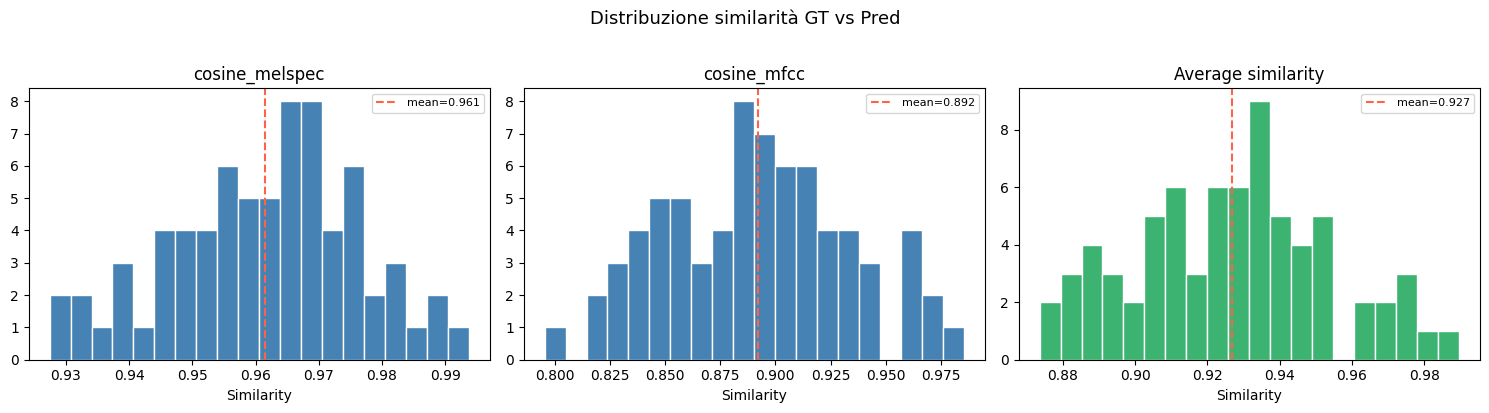


Similarità media complessiva: 0.9267
Mediana:                       0.9277
Max:                           0.9896
Min:                           0.8735


In [27]:
# ── Distribuzione delle similarità ───────────────────────────────────────
avg_scores = [r['avg_score'] for r in results]

fig, axes = plt.subplots(1, len(METRICS) + 1, figsize=(5 * (len(METRICS) + 1), 4))
for ax, metric in zip(axes[:-1], METRICS):
    vals = [r['scores'][metric] for r in results]
    ax.hist(vals, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel('Similarity')
    ax.axvline(np.mean(vals), color='tomato', linestyle='--', label=f'mean={np.mean(vals):.3f}')
    ax.legend(fontsize=8)

axes[-1].hist(avg_scores, bins=20, color='mediumseagreen', edgecolor='white')
axes[-1].set_title('Average similarity')
axes[-1].set_xlabel('Similarity')
axes[-1].axvline(np.mean(avg_scores), color='tomato', linestyle='--',
                  label=f'mean={np.mean(avg_scores):.3f}')
axes[-1].legend(fontsize=8)

plt.suptitle('Distribuzione similarità GT vs Pred', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSimilarità media complessiva: {np.mean(avg_scores):.4f}")
print(f"Mediana:                       {np.median(avg_scores):.4f}")
print(f"Max:                           {np.max(avg_scores):.4f}")
print(f"Min:                           {np.min(avg_scores):.4f}")

Sample index disponibili (72): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]



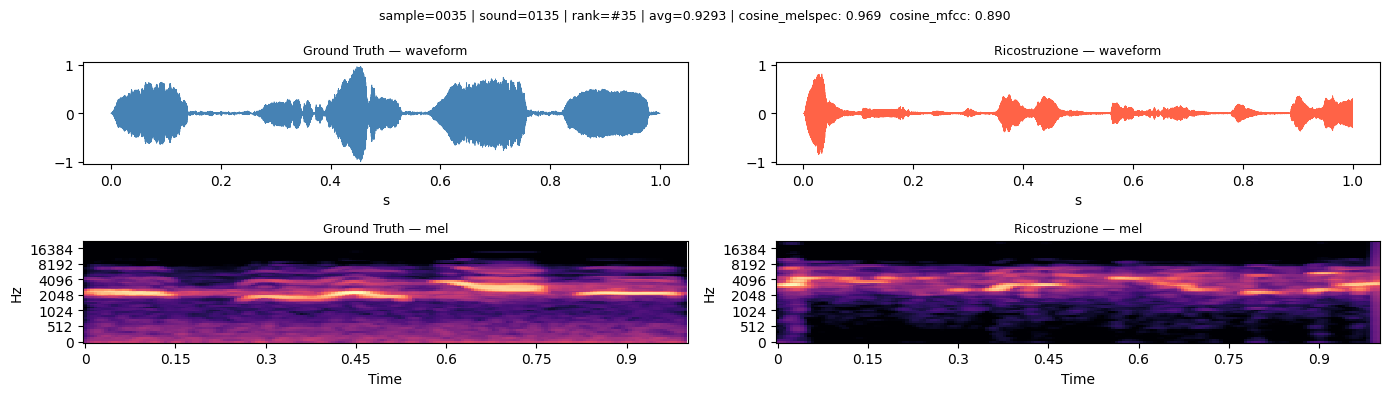

In [28]:
# ── Ascolta / plotta una coppia per sample_idx ──────────────────────────
# Imposta qui il sample index che vuoi ispezionare
SAMPLE_IDX = 35    # speech: 5, 2, 7, 9, 11
                  # voice: 14, 15, 17, 18, 21
                  # animal: 30, 31, 32, 35
                  # music: 40, 41, 43, 44, 45, 47
                  # nature: 48, 50, 55, 58, 59
                  # tool: 64, 66, 67, 71

def plot_and_play(sample_idx, sr=TARGET_SR):
    # Cerca nei risultati
    matches = [r for r in results if r['sample_idx'] == sample_idx]
    if not matches:
        available = sorted(set(r['sample_idx'] for r in results))
        print(f"Sample {sample_idx} non trovato. Disponibili: {available}")
        return

    r = matches[0]
    gt_wav   = load_wav(r['gt_path'])
    pred_wav = load_wav(r['pred_path'])

    fig = plt.figure(figsize=(14, 4))
    gs  = gridspec.GridSpec(2, 2, figure=fig)
    ax_gt_w   = fig.add_subplot(gs[0, 0])
    ax_pred_w = fig.add_subplot(gs[0, 1])
    ax_gt_m   = fig.add_subplot(gs[1, 0])
    ax_pred_m = fig.add_subplot(gs[1, 1])

    t  = np.linspace(0, len(gt_wav)   / sr, len(gt_wav))
    t2 = np.linspace(0, len(pred_wav) / sr, len(pred_wav))

    ax_gt_w.plot(t,  gt_wav,   color='steelblue', linewidth=0.5)
    ax_gt_w.set_title('Ground Truth — waveform', fontsize=9)
    ax_gt_w.set_xlabel('s'); ax_gt_w.set_ylim(-1.05, 1.05)

    ax_pred_w.plot(t2, pred_wav, color='tomato', linewidth=0.5)
    ax_pred_w.set_title('Ricostruzione — waveform', fontsize=9)
    ax_pred_w.set_xlabel('s'); ax_pred_w.set_ylim(-1.05, 1.05)

    mel_gt   = librosa.feature.melspectrogram(y=gt_wav,   sr=sr, n_mels=64, hop_length=256)
    mel_pred = librosa.feature.melspectrogram(y=pred_wav, sr=sr, n_mels=64, hop_length=256)
    librosa.display.specshow(librosa.power_to_db(mel_gt,   ref=np.max),
                             sr=sr, hop_length=256, x_axis='time', y_axis='mel', ax=ax_gt_m)
    librosa.display.specshow(librosa.power_to_db(mel_pred, ref=np.max),
                             sr=sr, hop_length=256, x_axis='time', y_axis='mel', ax=ax_pred_m)
    ax_gt_m.set_title('Ground Truth — mel', fontsize=9)
    ax_pred_m.set_title('Ricostruzione — mel', fontsize=9)

    score_str = '  '.join([f"{k}: {v:.3f}" for k, v in r['scores'].items()])
    rank = next((i for i, x in enumerate(results) if x['sample_idx'] == sample_idx), '?')
    fig.suptitle(
        f"sample={sample_idx:04d} | sound={r['sound_idx']:04d} | "
        f"rank=#{rank+1 if isinstance(rank,int) else rank} | avg={r['avg_score']:.4f} | {score_str}",
        fontsize=9
    )
    plt.tight_layout()
    plt.show()

    display(HTML(f"<b>▶ Ground Truth</b> &nbsp;<code>{os.path.basename(r['gt_path'])}</code>"))
    display(Audio(gt_wav,   rate=sr))
    display(HTML(f"<b>▶ Ricostruzione</b> &nbsp;<code>{os.path.basename(r['pred_path'])}</code>"))
    display(Audio(pred_wav, rate=sr))


# Mostra anche i sample index disponibili
available_samples = sorted(set(r['sample_idx'] for r in results))
print(f"Sample index disponibili ({len(available_samples)}): {available_samples}")
print()
plot_and_play(SAMPLE_IDX)

## Spettrogrammi animati (audio_see)
Genera un video `.mp4` per ogni file in `audio_see/`: mel-spettrogramma con cursore mobile + audio embedded.

In [70]:
import subprocess
import numpy as np
import soundfile as sf
import librosa
import librosa.display
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path

AUDIO_SEE_DIR = Path("/home/matteoc/brainSounds/maas_model/audio_see")
FFMPEG_BIN    = "/home/matteoc/miniconda3/envs/huggin/bin/ffmpeg"
FPS    = 25
N_MELS = 128
HOP    = 512
N_FFT  = 2048

matplotlib.rcParams["animation.ffmpeg_path"] = FFMPEG_BIN


def make_spectrogram_video(audio_path: Path, fps: int = FPS) -> Path:
    out_path = audio_path.with_name(audio_path.stem + "_spec.mp4")
    tmp_path = audio_path.with_name(audio_path.stem + "_tmp.mp4")

    # ── carica audio ──────────────────────────────────────────────────────
    audio, sr = sf.read(str(audio_path))
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    audio    = audio.astype(np.float32)
    duration = len(audio) / sr

    # ── mel spectrogram ───────────────────────────────────────────────────
    mel    = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # ── figura con cursore ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=HOP,
                                   x_axis="time", y_axis="mel",
                                   cmap="magma", ax=ax)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")
    ax.set_title(audio_path.stem, fontsize=10)
    fig.tight_layout()

    xlim   = ax.get_xlim()
    cursor = ax.axvline(x=xlim[0], color="white", linewidth=2, alpha=0.88)
    n_frames = max(1, int(duration * fps))

    def update(frame):
        t = frame / fps
        x = xlim[0] + (t / duration) * (xlim[1] - xlim[0])
        cursor.set_xdata([x, x])
        return (cursor,)

    anim = animation.FuncAnimation(fig, update, frames=n_frames,
                                   interval=1000 / fps, blit=True)

    # libopenh264 è disponibile nell'env huggin (libx264 non presente)
    writer = animation.FFMpegWriter(fps=fps, codec="libopenh264",
                                    extra_args=["-pix_fmt", "yuv420p", "-b:v", "3000k"])
    anim.save(str(tmp_path), writer=writer)
    plt.close(fig)

    # ── mux audio ────────────────────────────────────────────────────────
    subprocess.run(
        [FFMPEG_BIN, "-y", "-loglevel", "error",
         "-i", str(tmp_path),
         "-i", str(audio_path),
         "-c:v", "copy", "-c:a", "aac", "-b:a", "192k", "-shortest",
         str(out_path)],
        check=True,
    )
    tmp_path.unlink(missing_ok=True)
    return out_path


# ── processa tutti i .wav ─────────────────────────────────────────────────
wav_files = sorted(AUDIO_SEE_DIR.glob("*.wav"))
print(f"File .wav trovati: {len(wav_files)}\n")

for wav_path in wav_files:
    out = wav_path.with_name(wav_path.stem + "_spec.mp4")
    if out.exists():
        print(f"  [skip] {out.name}")
        continue
    print(f"  Genero {out.name} ...", end=" ", flush=True)
    try:
        make_spectrogram_video(wav_path)
        print("ok")
    except Exception as exc:
        print(f"ERRORE: {exc}")

print(f"\nFatto! Video in: {AUDIO_SEE_DIR}")

File .wav trovati: 18

  Genero bambino_piange_gen_spec.mp4 ... ok
  Genero bamgino_piange_true_spec.mp4 ... ok
  Genero flute_gen_spec.mp4 ... ok
  Genero flute_true_spec.mp4 ... ok
  Genero guitar_gen_spec.mp4 ... ok
  Genero guitar_true_spec.mp4 ... ok
  Genero music1_gen_spec.mp4 ... ok
  Genero music1_true_spec.mp4 ... ok
  Genero scimmia_gen_spec.mp4 ... ok
  Genero scimmia_true_spec.mp4 ... ok
  Genero temporale_gen_spec.mp4 ... ok
  Genero temporale_true_spec.mp4 ... ok
  Genero uccello_gen_spec.mp4 ... ok
  Genero uccello_true_spec.mp4 ... ok
  Genero voice_female_gen_spec.mp4 ... ok
  Genero voice_female_true_spec.mp4 ... ok
  Genero voice_male_gen_spec.mp4 ... ok
  Genero voice_male_true_spec.mp4 ... ok

Fatto! Video in: /home/matteoc/brainSounds/maas_model/audio_see


## ROI ablation per blocks

Prediction files trovati:
 - pred_keep_HG2hem_PP2hem_sound0084_sample0021.wav

Ground-truth files trovati:

Uso prediction: pred_keep_HG2hem_PP2hem_sound0084_sample0021.wav

Ascolto prediction


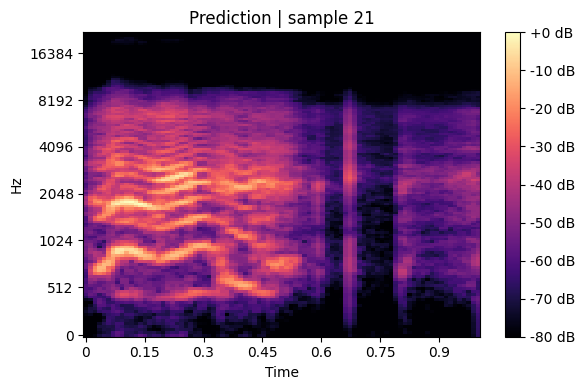

In [11]:
from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

output_dir = Path("/srv/nfs-data/sisko/matteoc/maas_2023/decoded_roi_subset")
sample_idx = SAMPLE_IDX

# Esempi:
# None
# "keep_HG2hem_PP2hem"
# "keep_mSTG2hem_pSTG2hem"
selection_filter = "keep_HG2hem_PP2hem"

def find_sample_files(base_dir, prefix, sample_idx, selection_filter=None):
    patterns = [
        f"{prefix}_*sample{sample_idx}.wav",
        f"{prefix}_*sample{sample_idx:03d}.wav",
        f"{prefix}_*sample{sample_idx:04d}.wav",
    ]
    files = []
    for pat in patterns:
        files.extend(base_dir.glob(pat))
    files = sorted(set(files))
    if selection_filter is not None:
        files = [p for p in files if selection_filter in p.name]
    return files

pred_files = find_sample_files(output_dir, "pred", sample_idx, selection_filter)
gt_files = find_sample_files(output_dir, "gt", sample_idx, selection_filter)

print("Prediction files trovati:")
for p in pred_files:
    print(" -", p.name)

print("\nGround-truth files trovati:")
for p in gt_files:
    print(" -", p.name)

if not pred_files:
    raise ValueError(f"Nessun file pred trovato per sample_idx={sample_idx}")

pred_path = pred_files[0]
gt_path = gt_files[0] if gt_files else None

print(f"\nUso prediction: {pred_path.name}")
if gt_path is not None:
    print(f"Uso ground truth: {gt_path.name}")

def load_audio(path):
    audio, sr = sf.read(path)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    return audio.astype(np.float32), sr

pred_audio, pred_sr = load_audio(pred_path)
gt_audio, gt_sr = load_audio(gt_path) if gt_path is not None else (None, None)

print("\nAscolto prediction")
display(Audio(pred_audio, rate=pred_sr))

if gt_audio is not None:
    print("Ascolto ground truth")
    display(Audio(gt_audio, rate=gt_sr))

def log_mel(audio, sr, n_mels=128, hop_length=512, n_fft=2048, fmax=None):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0,
        fmax=fmax,
    )
    return librosa.power_to_db(mel, ref=np.max)

pred_spec = log_mel(pred_audio, pred_sr)

if gt_audio is not None:
    if gt_sr != pred_sr:
        gt_audio = librosa.resample(gt_audio, orig_sr=gt_sr, target_sr=pred_sr)
        gt_sr = pred_sr
    gt_spec = log_mel(gt_audio, gt_sr)
    min_t = min(pred_spec.shape[1], gt_spec.shape[1])
    delta_spec = np.abs(pred_spec[:, :min_t] - gt_spec[:, :min_t])
else:
    gt_spec = None
    delta_spec = None

ncols = 3 if gt_spec is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))
if ncols == 1:
    axes = [axes]

img0 = librosa.display.specshow(pred_spec, sr=pred_sr, x_axis="time", y_axis="mel", cmap="magma", ax=axes[0])
axes[0].set_title(f"Prediction | sample {sample_idx}")
fig.colorbar(img0, ax=axes[0], format="%+2.0f dB")

if gt_spec is not None:
    img1 = librosa.display.specshow(gt_spec, sr=gt_sr, x_axis="time", y_axis="mel", cmap="magma", ax=axes[1])
    axes[1].set_title("Ground truth")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    img2 = librosa.display.specshow(delta_spec, sr=pred_sr, x_axis="time", y_axis="mel", cmap="viridis", ax=axes[2])
    axes[2].set_title("|Prediction - GT|")
    fig.colorbar(img2, ax=axes[2])

plt.tight_layout()
plt.show()
